# Notebook 3 - Gradient Descent with Adam

This notebook implement Adam. It includes:
- a small 2-layer neural network
- Adam optimizer
- simple gradient descent
- two examples: circles and sinusoidal classification


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Make a nonlinear dataset

We will use the same datasets as before: circles and sinusoidal curves

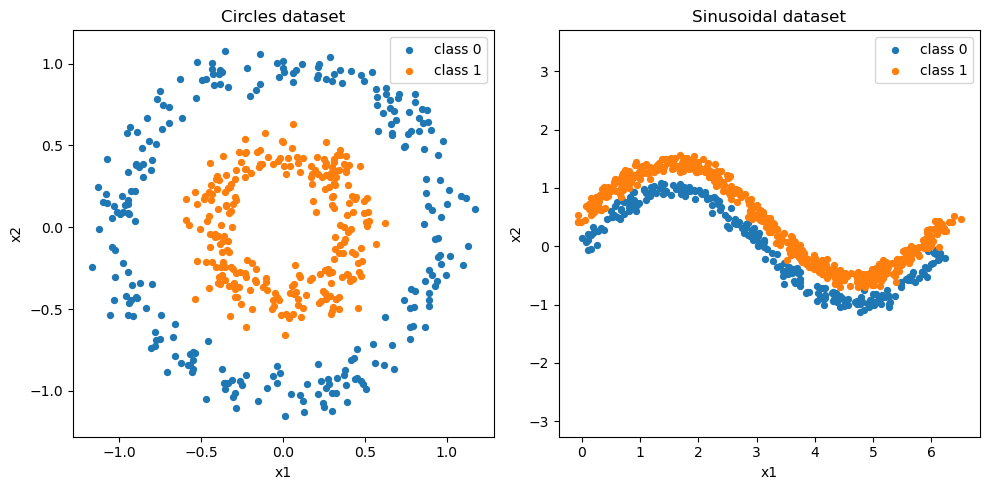

In [2]:
# ---------------------------
# datasets
# ---------------------------
def make_circles(n=400, noise=0.08, factor=0.45, seed=42):
    rng = np.random.default_rng(seed)
    n_outer = n // 2
    n_inner = n - n_outer

    theta_outer = rng.uniform(0, 2*np.pi, n_outer)
    theta_inner = rng.uniform(0, 2*np.pi, n_inner)

    outer = np.column_stack([np.cos(theta_outer), np.sin(theta_outer)])
    inner = factor * np.column_stack([np.cos(theta_inner), np.sin(theta_inner)])

    X = np.vstack([outer, inner])
    y = np.concatenate([np.zeros(n_outer), np.ones(n_inner)])

    X += noise * rng.normal(size=X.shape)
    return X, y.astype(int)


def make_sinusoidal(n=400, noise=0.08, shift=0.45, seed=42):
    rng = np.random.default_rng(seed)
    n_1 = n // 2
    n_2 = n - 1

    phi_1 = rng.uniform(0, 2*np.pi, n_1)
    phi_2 = rng.uniform(0, 2*np.pi, n_2)

    curve_1 = np.column_stack([phi_1, np.sin(phi_1)])
    curve_2 = np.column_stack([phi_2, np.sin(phi_2)+shift])

    X = np.vstack([curve_1, curve_2])
    y = np.concatenate([np.zeros(n_1), np.ones(n_2)])

    X += noise * rng.normal(size=X.shape)
    return X, y.astype(int)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=False, sharey=False)

# circles
X1, y1 = make_circles(n=500, noise=0.08, factor=0.45, seed=42)
axs[0].scatter(X1[y1 == 0, 0], X1[y1 == 0, 1], s=18, label="class 0")
axs[0].scatter(X1[y1 == 1, 0], X1[y1 == 1, 1], s=18, label="class 1")
axs[0].set_xlabel("x1")
axs[0].set_ylabel("x2")
axs[0].set_title("Circles dataset")
axs[0].legend()
axs[0].axis("equal")

# sinusoidal
X2, y2 = make_sinusoidal(n=500, noise=0.08, seed=42)
axs[1].scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], s=18, label="class 0")
axs[1].scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], s=18, label="class 1")
axs[1].set_xlabel("x1")
axs[1].set_ylabel("x2")
axs[1].set_title("Sinusoidal dataset")
axs[1].legend()
axs[1].axis("equal")

plt.tight_layout()
plt.show()

## 2. Basic gradient descent

First we review the basic gradient descent method we implemented in the last notebook.

In [3]:
# ---------------------------
# model
# ---------------------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def accuracy(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return np.mean(y_pred == y_true)

def init_params(input_dim=2, hidden_dim=16, seed=42):
    rng = np.random.default_rng(seed)
    return {
        "W1": 0.5 * rng.normal(size=(input_dim, hidden_dim)),
        "b1": np.zeros(hidden_dim),
        "W2": 0.5 * rng.normal(size=(hidden_dim, 1)),
        "b2": np.zeros(1),
    }

def forward(X, params):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]

    Z1 = X @ W1 + b1
    A1 = np.tanh(Z1)
    Z2 = A1 @ W2 + b2
    Y_prob = sigmoid(Z2).ravel()

    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "Y_prob": Y_prob}
    return Y_prob, cache

def backward(y_true, params, cache):
    X = cache["X"]
    A1 = cache["A1"]
    Y_prob = cache["Y_prob"]
    W2 = params["W2"]

    m = X.shape[0]

    dZ2 = (Y_prob - y_true).reshape(-1, 1) / m
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (1 - A1**2)
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

# ---------------------------
# basic gradient descent 
# ---------------------------
def update(params, grads, lr=0.1):
    for k in params:
        params[k] = params[k] - lr * grads[k]
    return params

def train_nn(X, y, hidden_dim=16, lr=0.1, steps=3000, seed=42, print_every=500):
    params = init_params(input_dim=X.shape[1], hidden_dim=hidden_dim, seed=seed)
    hist = {"loss": [], "acc": []}

    for step in range(steps):
        y_prob, cache = forward(X, params)
        loss = binary_cross_entropy(y, y_prob)
        acc = accuracy(y, y_prob)

        grads = backward(y, params, cache)
        params = update(params, grads, lr=lr)

        hist["loss"].append(loss)
        hist["acc"].append(acc)

        if step % print_every == 0 or step == steps :
            print(f"step={step:4d}   loss={loss:.4f}   acc={acc:.4f}")

    return params, hist

# ---------------------------
# plotting
# ---------------------------
def plot_nn_results(X, y, params, hist):
    fig = plt.figure(figsize=(11, 5.5))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.6, 1], hspace=0.28, wspace=0.3)

    ax_left = fig.add_subplot(gs[:, 0])
    ax_top = fig.add_subplot(gs[0, 1])
    ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_top)

    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 250),
        np.linspace(x2_min, x2_max, 250),
    )
    grid = np.column_stack([xx1.ravel(), xx2.ravel()])
    y_prob_grid, _ = forward(grid, params)
    prob = y_prob_grid.reshape(xx1.shape)

    ax_left.contourf(xx1, xx2, prob, levels=np.linspace(0, 1, 21), alpha=0.35)
    ax_left.contour(xx1, xx2, prob, levels=[0.5], linewidths=2)

    ax_left.scatter(X[y == 0, 0], X[y == 0, 1], s=18, label="class 0")
    ax_left.scatter(X[y == 1, 0], X[y == 1, 1], s=18, label="class 1")
    ax_left.set_xlabel("x1")
    ax_left.set_ylabel("x2")
    ax_left.set_title("Neural network decision boundary")
    ax_left.legend()
    #ax_left.axis("equal")

    ax_top.plot(hist["acc"])
    ax_top.set_ylabel("accuracy")
    ax_top.set_title("Training accuracy")
    ax_top.tick_params(labelbottom=False)

    ax_bottom.plot(hist["loss"])
    ax_bottom.set_xlabel("step")
    ax_bottom.set_ylabel("binary cross-entropy")
    ax_bottom.set_title("Training loss")

    plt.tight_layout()
    plt.show()

### 2.1 Example 1: Circles with basic gradient descent

step=   0   loss=0.7082   acc=0.5025
step= 500   loss=0.5690   acc=0.8350
step=1000   loss=0.2919   acc=0.9725
step=1500   loss=0.1315   acc=1.0000
step=2000   loss=0.0785   acc=1.0000
step=2500   loss=0.0546   acc=1.0000


/tmp/ipykernel_3681557/1039229891.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


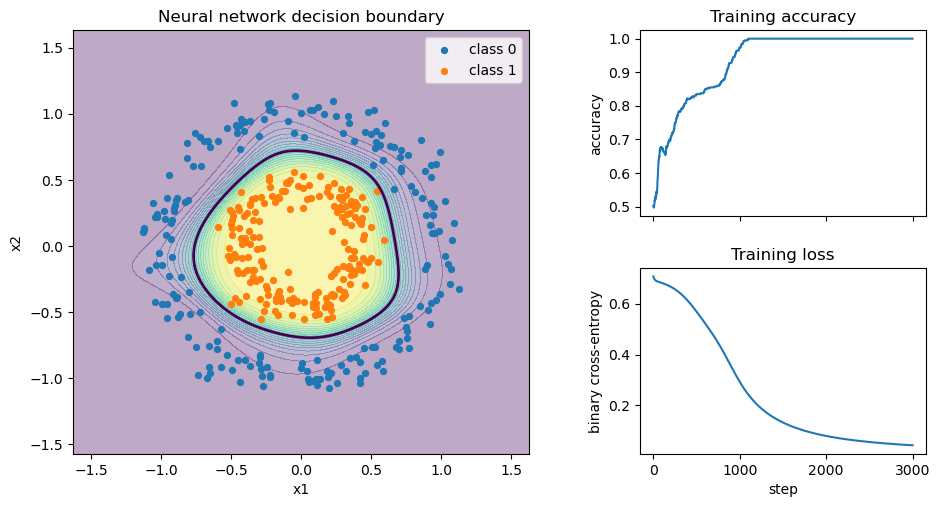

In [4]:
X, y = make_circles(n=400, noise=0.08, factor=0.45, seed=42)
params, hist = train_nn(X, y, hidden_dim=16, lr=0.1, steps=3000, seed=42, print_every=500)
plot_nn_results(X, y, params, hist)

### 2.12 Example 2: Sinusoidal curves with basic gradient descent
We can see the learning becomes unstable near the end, while the final accuracy is only 0.98.

step=   0   loss=0.8716   acc=0.3391
step= 500   loss=0.4622   acc=0.8037
step=1000   loss=0.4060   acc=0.8451
step=1500   loss=0.3606   acc=0.8838
step=2000   loss=0.3186   acc=0.9105
step=2500   loss=0.2797   acc=0.9319
step=3000   loss=0.2466   acc=0.9386
step=3500   loss=0.2156   acc=0.9453
step=4000   loss=0.2097   acc=0.9332
step=4500   loss=0.1888   acc=0.9413
step=5000   loss=0.1695   acc=0.9453
step=5500   loss=0.1517   acc=0.9613
step=6000   loss=0.1354   acc=0.9680
step=6500   loss=0.1209   acc=0.9733
step=7000   loss=0.1080   acc=0.9760
step=7500   loss=0.0966   acc=0.9786


/tmp/ipykernel_3681557/1039229891.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


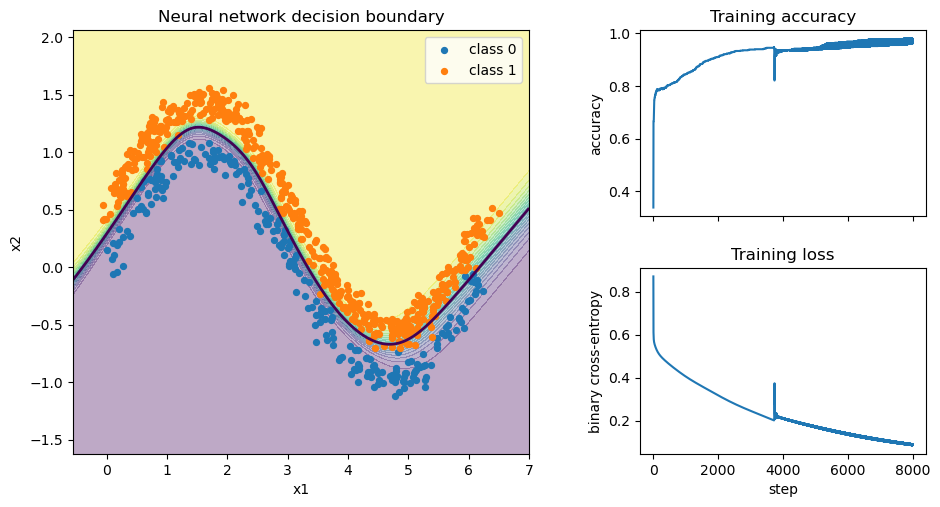

In [5]:
X, y = make_sinusoidal(n=500, noise=0.08, shift=0.45, seed=42)

params, hist = train_nn(X, y, hidden_dim=32, lr=0.1, steps=8000, seed=42, print_every=500)
plot_nn_results(X, y, params, hist)

y_prob, _ = forward(X, params)

## 3. What is Adam?

Adam stands for **Adaptive Moment Estimation**.

### Cores
In plain gradient descent, every parameter is updated as

$$
\theta \leftarrow \theta - \eta g
$$

where $g$ is the current gradient and $\eta$ is the learning rate.

Adam improves this in two ways:

1. **Momentum**
   
   Adam keeps a running average of past gradients:
   
   $$
   m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t
   $$
   
   This smooths noisy gradients and gives a more stable update direction.

2. **Adaptive scaling**
   
   Adam also keeps a running average of squared gradients:
   
   $$
   v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
   $$
   
   If a parameter often has large gradients, Adam scales its update down. If it has smaller gradients, Adam allows a relatively larger update.

The update rule is

$$
\theta_t = \theta_{t-1} -  \frac{\eta \hat m_t}{\sqrt{\hat v_t} + \epsilon}
$$

where $\hat m_t$ and $\hat v_t$ are the bias-corrected versions of $m_t$ and $v_t$.

### Intuition

A useful way to think about Adam is:

- $m$: the recent average gradient direction
- $v$: the recent average gradient magnitude

So Adam moves in a smoothed direction, while automatically adjusting the effective step size for each parameter.

### Why bias correction is needed

At the beginning of training, both $m_t$ and $v_t$ start from zero, so they are initially biased toward zero. Adam corrects for this using

$$
\hat m_t = \frac{m_t}{1-\beta_1^t}, \qquad
\hat v_t = \frac{v_t}{1-\beta_2^t}.
$$

This makes the early updates more accurate.

### Why Adam is useful

Adam is often a good default optimizer because it:

- converges faster than plain gradient descent in many cases
- is less sensitive to the exact learning rate
- works well when gradients are noisy
- adapts to different parameter scales automatically

### Implementation

The cell below implements Adam.

In [6]:
# ---------------------------
# Adam
# ---------------------------
def init_adam_state(params):
    state = {"m": {}, "v": {}, "t": 0}
    for k in params:
        state["m"][k] = np.zeros_like(params[k])
        state["v"][k] = np.zeros_like(params[k])
    return state


def adam_update(params, grads, state, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
    state["t"] += 1
    t = state["t"]

    for k in params:
        state["m"][k] = beta1 * state["m"][k] + (1 - beta1) * grads[k]
        state["v"][k] = beta2 * state["v"][k] + (1 - beta2) * (grads[k] ** 2)

        m_hat = state["m"][k] / (1 - beta1**t)
        v_hat = state["v"][k] / (1 - beta2**t)

        params[k] = params[k] - lr * m_hat / (np.sqrt(v_hat) + eps)

    return params, state


def train_nn_adam(X, y, hidden_dim=16, lr=0.01, steps=3000, seed=42, print_every=500):
    params = init_params(input_dim=X.shape[1], hidden_dim=hidden_dim, seed=seed)
    state = init_adam_state(params)

    hist = {"loss": [], "acc": []}

    for step in range(steps):
        y_prob, cache = forward(X, params)
        loss = binary_cross_entropy(y, y_prob)
        acc = accuracy(y, y_prob)

        grads = backward(y, params, cache)
        params, state = adam_update(params, grads, state, lr=lr)

        hist["loss"].append(loss)
        hist["acc"].append(acc)

        if step % print_every == 0 or step == steps - 1:
            print(f"step={step:5d}   loss={loss:.4f}   acc={acc:.4f}")

    return params, hist




## 4. Example of using Adam

Now we apply Adam on the two examples.

Common default hyperparameters are:

- learning rate: `lr = 0.1` for small toy problems
- $\beta_1 = 0.9$
- $\beta_2 = 0.999$
- $\epsilon = 10^{-8}$



### Example 1: circles

step=    0   loss=0.7359   acc=0.4925
step=  500   loss=0.0007   acc=1.0000
step= 1000   loss=0.0002   acc=1.0000
step= 1500   loss=0.0001   acc=1.0000
step= 2000   loss=0.0001   acc=1.0000
step= 2500   loss=0.0000   acc=1.0000
step= 2999   loss=0.0000   acc=1.0000


/tmp/ipykernel_3681557/1039229891.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


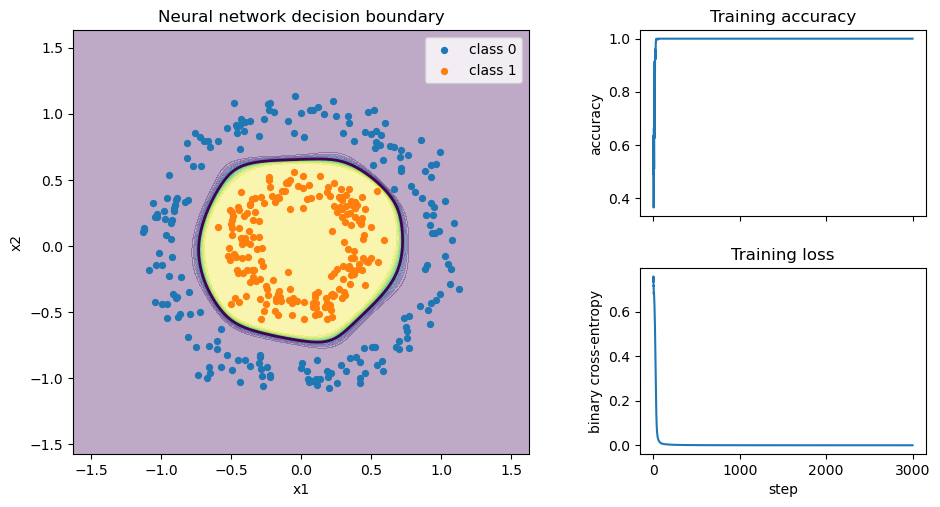

In [7]:
X, y = make_circles(n=400, noise=0.08, factor=0.45, seed=42)
params, hist = train_nn_adam(X, y, hidden_dim=32, lr=0.1, steps=3000, seed=42, print_every=500)
plot_nn_results(X, y, params, hist)

### Example 2: sinusoidal

step=    0   loss=0.8752   acc=0.3356
step=  500   loss=0.0182   acc=0.9933
step= 1000   loss=0.0104   acc=0.9983
step= 1500   loss=0.0071   acc=1.0000
step= 2000   loss=0.0157   acc=0.9967
step= 2500   loss=0.0049   acc=1.0000
step= 3000   loss=0.0036   acc=1.0000
step= 3500   loss=0.0027   acc=1.0000
step= 4000   loss=0.0019   acc=1.0000
step= 4500   loss=0.0014   acc=1.0000
step= 5000   loss=0.0010   acc=1.0000
step= 5500   loss=0.0007   acc=1.0000
step= 6000   loss=0.0005   acc=1.0000
step= 6500   loss=0.0003   acc=1.0000
step= 7000   loss=0.0002   acc=1.0000
step= 7500   loss=0.0002   acc=1.0000
step= 7999   loss=0.0001   acc=1.0000


/tmp/ipykernel_3681557/1039229891.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


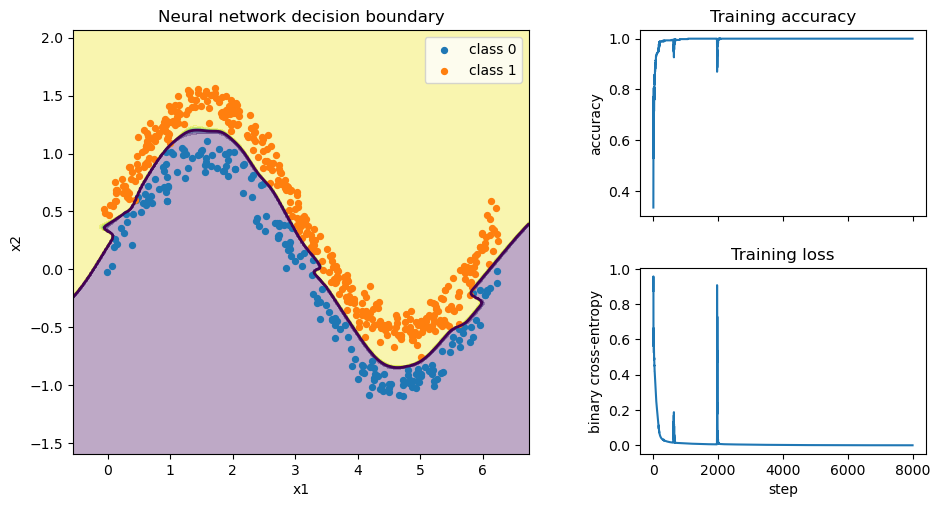

In [8]:
X, y = make_sinusoidal(n=400, noise=0.08, shift=0.45, seed=42)
params, hist = train_nn_adam(X, y, hidden_dim=32, lr=0.1, steps=8000, seed=42, print_every=500)
plot_nn_results(X, y, params, hist)

## 5. Adam vs. basic gradient descent

Finally, we compare Adam and basic gradient descent on the same two datasets.

In this notebook, both methods use the same network architecture, initialization seed, and learning rate. The main difference is the optimizer itself.

Things to look for in the comparison:

- how quickly the loss decreases;
- how smooth or noisy the training curve is;
- the final training accuracy.

Circles dataset
step=   0   loss=0.7359   acc=0.4925
step=2500   loss=0.6291   acc=0.8125
step=5000   loss=0.5003   acc=0.9025
step=7500   loss=0.3402   acc=0.9900
step=    0   loss=0.7359   acc=0.4925
step= 2500   loss=0.0004   acc=1.0000
step= 5000   loss=0.0001   acc=1.0000
step= 7500   loss=0.0000   acc=1.0000
step= 9999   loss=0.0000   acc=1.0000


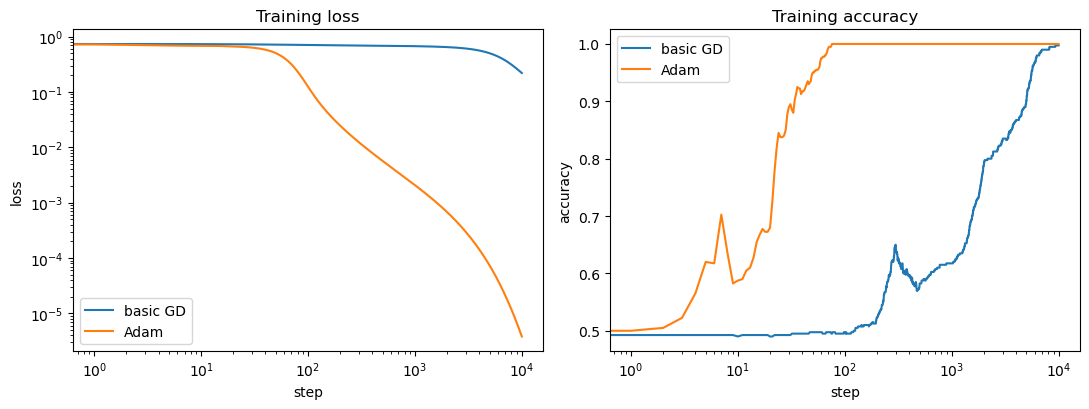

basic GD final loss = 0.2198, final acc = 0.9975
Adam     final loss = 0.0000, final acc = 1.0000

Sinusoidal dataset
step=   0   loss=0.8752   acc=0.3356
step=2500   loss=0.4951   acc=0.7930
step=5000   loss=0.4591   acc=0.8180
step=7500   loss=0.4270   acc=0.8381
step=    0   loss=0.8752   acc=0.3356
step= 2500   loss=0.0143   acc=0.9950
step= 5000   loss=0.0040   acc=1.0000
step= 7500   loss=0.0010   acc=1.0000
step= 9999   loss=0.0003   acc=1.0000


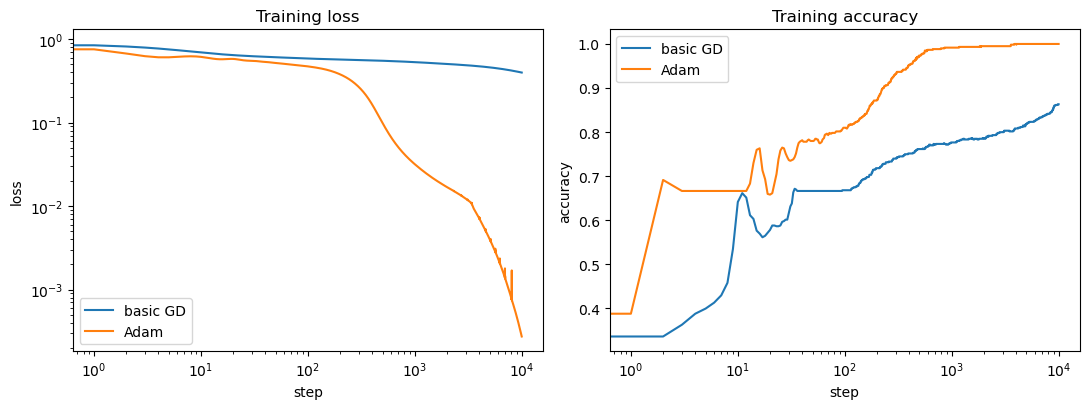

basic GD final loss = 0.3978, final acc = 0.8631
Adam     final loss = 0.0003, final acc = 1.0000


In [19]:
def compare_optimizers(X, y, hidden_dim=32, lr=0.05, steps=3000, seed=42):
    params_gd, hist_gd = train_nn(
        X, y, hidden_dim=hidden_dim, lr=lr, steps=steps, seed=seed, print_every=steps//4
    )
    params_adam, hist_adam = train_nn_adam(
        X, y, hidden_dim=hidden_dim, lr=lr, steps=steps, seed=seed, print_every=steps//4
    )

    fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))

    axs[0].plot(hist_gd['loss'], label='basic GD')
    axs[0].plot(hist_adam['loss'], label='Adam')
    axs[0].set_xlabel('step')
    axs[0].set_ylabel('loss')
    axs[0].set_title('Training loss')
    axs[0].legend()

    axs[1].plot(hist_gd['acc'], label='basic GD')
    axs[1].plot(hist_adam['acc'], label='Adam')
    axs[1].set_xlabel('step')
    axs[1].set_ylabel('accuracy')
    axs[1].set_title('Training accuracy')
    axs[1].legend()
    
    axs[0].set_xscale('log')
    axs[1].set_xscale('log')
    axs[0].set_yscale('log')
    #axs[1].set_yscale('log')
    
    plt.tight_layout()
    plt.show()

    print(f"basic GD final loss = {hist_gd['loss'][-1]:.4f}, final acc = {hist_gd['acc'][-1]:.4f}")
    print(f"Adam     final loss = {hist_adam['loss'][-1]:.4f}, final acc = {hist_adam['acc'][-1]:.4f}")

    return (params_gd, hist_gd), (params_adam, hist_adam)

# comparison on circles
X, y = make_circles(n=400, noise=0.08, factor=0.45, seed=42)
print('Circles dataset')
_ = compare_optimizers(X, y, hidden_dim=32, lr=0.01, steps=10000, seed=42)

# comparison on sinusoidal
X, y = make_sinusoidal(n=400, noise=0.08, shift=0.45, seed=42)
print('\nSinusoidal dataset')
_ = compare_optimizers(X, y, hidden_dim=32, lr=0.01, steps=10000, seed=42)


## 6. Takeaway

For these toy nonlinear classification problems, Adam usually reaches a good solution faster and with smoother optimization than basic gradient descent.

Basic gradient descent can still work, but it is often more sensitive to the learning rate and may show slower or less stable progress, especially on the sinusoidal example.